In [4]:
import os
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import cv2
import tensorflow as tf
import random
import shutil             # to copy images to another directory
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report , confusion_matrix

from tqdm import tqdm
from keras.layers import Conv2D, MaxPooling2D , BatchNormalization ,Dropout ,Flatten , Dense , Input , Rescaling , Resizing
from keras.models import Sequential
from tensorflow.keras.preprocessing.image import ImageDataGenerator, array_to_img, img_to_array, load_img
from tensorflow.keras.applications import MobileNetV2 #( i changed my model to ResNet-50 )

import warnings

with warnings.catch_warnings():
    warnings.simplefilter("ignore")

plt.style.use('ggplot')

In [5]:
!pip -q install kaggle

from google.colab import files
print("👉 Please upload your kaggle.json")
files.upload();  # select kaggle.json

!mkdir -p ~/.kaggle
!cp kaggle.json ~/.kaggle/
!chmod 600 ~/.kaggle/kaggle.json


👉 Please upload your kaggle.json


Saving kaggle.json to kaggle (1).json


In [6]:
# Download
!kaggle datasets download -d mostafaabla/garbage-classification -p /content

# Unzip (quietly) to a fixed folder
!mkdir -p /content/garbage_data
!unzip -q /content/garbage-classification.zip -d /content/garbage_data


Dataset URL: https://www.kaggle.com/datasets/mostafaabla/garbage-classification
License(s): ODbL-1.0
 74% 176M/239M [00:00<00:00, 1.84GB/s]
100% 239M/239M [00:00<00:00, 1.85GB/s]


In [7]:
import os, pandas as pd

# Classes you want to keep (and merge white-glass -> glass)
selectedClasses = ['metal', 'glass', 'paper', 'trash', 'cardboard', 'plastic', 'white-glass']

root_dir = "/content/garbage_data"   # where we unzipped

imgPaths, labels = [], []

for dirpath, dirnames, filenames in os.walk(root_dir):
    base = os.path.basename(dirpath).strip().lower()
    if base in selectedClasses:
        for fn in filenames:
            if fn.lower().endswith((".jpg", ".jpeg", ".png", ".bmp", ".gif", ".tif", ".tiff", ".webp")):
                full_path = os.path.join(dirpath, fn)
                cls = 'glass' if base == 'white-glass' else base
                imgPaths.append(full_path)
                labels.append(cls)

df = pd.DataFrame({"imgPath": imgPaths, "label": labels}).sample(frac=1).reset_index(drop=True)

print("Loaded images:", len(df))
print(df['label'].value_counts())
df.head()


Loaded images: 5047
label
paper        1050
cardboard     891
plastic       865
glass         775
metal         769
trash         697
Name: count, dtype: int64


,imgPath,label
0,/content/garbage_data/garbage_classification/w...,glass
1,/content/garbage_data/garbage_classification/c...,cardboard
2,/content/garbage_data/garbage_classification/c...,cardboard
3,/content/garbage_data/garbage_classification/m...,metal
4,/content/garbage_data/garbage_classification/t...,trash


In [8]:
# Split dataframe so each class keeps the same ratio (e.g. 85% train, 15% test)
def DataFrameSplitting(df, ratio, classesList):
    trainDf = pd.DataFrame(columns=['imgPath', 'label'])
    testDf  = pd.DataFrame(columns=['imgPath', 'label'])

    for cls in classesList:
        tempDf = df[df['label'] == cls]
        lastIndex = int(len(tempDf) * ratio)
        trainClassDf = tempDf.iloc[:lastIndex]
        testClassDf  = tempDf.iloc[lastIndex:]
        trainDf = pd.concat([trainDf, trainClassDf], axis=0)
        testDf  = pd.concat([testDf,  testClassDf],  axis=0)

    # Shuffle both sets
    trainDf = trainDf.sample(frac=1).reset_index(drop=True)
    testDf  = testDf.sample(frac=1).reset_index(drop=True)
    return trainDf, testDf


In [9]:
classList = list(df['label'].unique())     # unique class names
trainDf, testDf = DataFrameSplitting(df, 0.85, classList)


In [10]:
print("Train size:", len(trainDf))
print("Test size:", len(testDf))
print("\nLabel counts in Train:")
print(trainDf['label'].value_counts())
print("\nLabel counts in Test:")
print(testDf['label'].value_counts())

trainDf.head()


Train size: 4287
Test size: 760

Label counts in Train:
label
paper        892
cardboard    757
plastic      735
glass        658
metal        653
trash        592
Name: count, dtype: int64

Label counts in Test:
label
paper        158
cardboard    134
plastic      130
glass        117
metal        116
trash        105
Name: count, dtype: int64


,imgPath,label
0,/content/garbage_data/garbage_classification/c...,cardboard
1,/content/garbage_data/garbage_classification/c...,cardboard
2,/content/garbage_data/garbage_classification/m...,metal
3,/content/garbage_data/garbage_classification/p...,plastic
4,/content/garbage_data/garbage_classification/m...,metal


In [11]:
trainDf.to_csv('/content/train_split.csv', index=False)
testDf.to_csv('/content/test_split.csv', index=False)


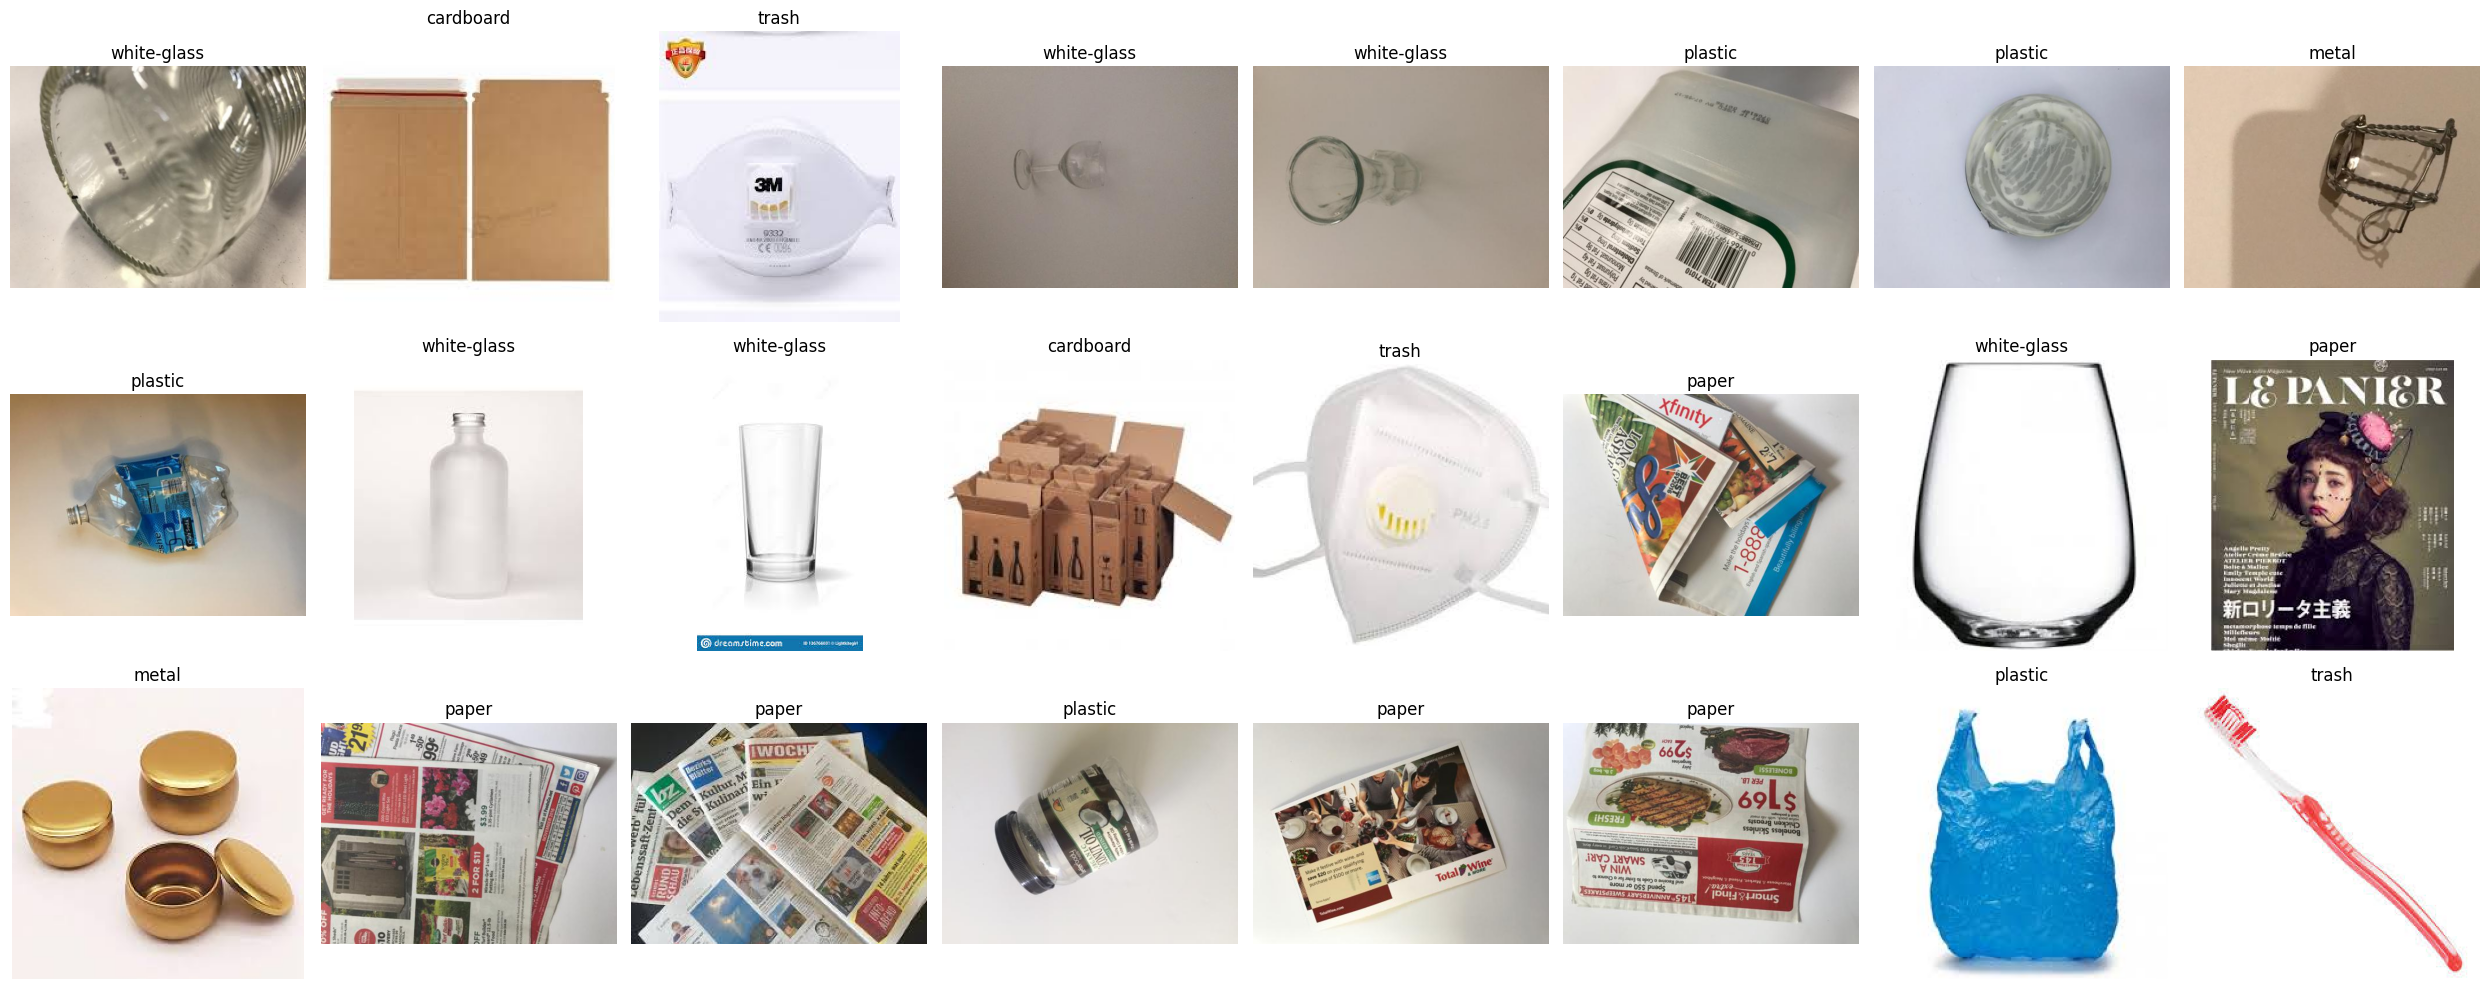

In [12]:
import matplotlib.pyplot as plt
import cv2

# Select image paths from dataframe
imgPaths = df['imgPath'].sample(24).values   # random 24 samples for display

# Create figure
fig, axs = plt.subplots(3, 8, figsize=(25, 10))
axs = axs.flatten()

for ax, imgPath in zip(axs, imgPaths):
    label = str(imgPath).split('/')[-2]      # extract folder name as label
    img = cv2.imread(imgPath)                # read with OpenCV (BGR)
    if img is not None:
        img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)  # convert to RGB for plt
        ax.imshow(img)
        ax.set_title(label, fontsize=12)
        ax.axis('off')
    else:
        ax.set_visible(False)                # skip missing files

plt.tight_layout()
plt.show()


# ***Data augmentation***

In [13]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator


In [14]:
datagenTrain = ImageDataGenerator(
    rescale=1./255,
    zoom_range=(1.0, 1.2),     # zoom in
    horizontal_flip=True,
    vertical_flip=True,
    rotation_range=45
)
IMG_SIZE = (224, 224)
trainGenerator = datagenTrain.flow_from_dataframe(
    trainDf,
    x_col='imgPath',
    y_col='label',
    target_size=IMG_SIZE,
    batch_size=64,              # how many images per batch
    class_mode='categorical'    # multi-class labels
)
datagenTest = ImageDataGenerator(rescale=1./255)

testGenerator = datagenTest.flow_from_dataframe(
    testDf,
    x_col='imgPath',
    y_col='label',
    target_size=IMG_SIZE,
    batch_size=8,
    class_mode='categorical',
    shuffle=False
)

print(f"Training set size: {trainGenerator.samples}")
print(f"Testing set size: {testGenerator.samples}")


Found 4287 validated image filenames belonging to 6 classes.
Found 760 validated image filenames belonging to 6 classes.
Training set size: 4287
Testing set size: 760


# ***Preview Augmented Images***

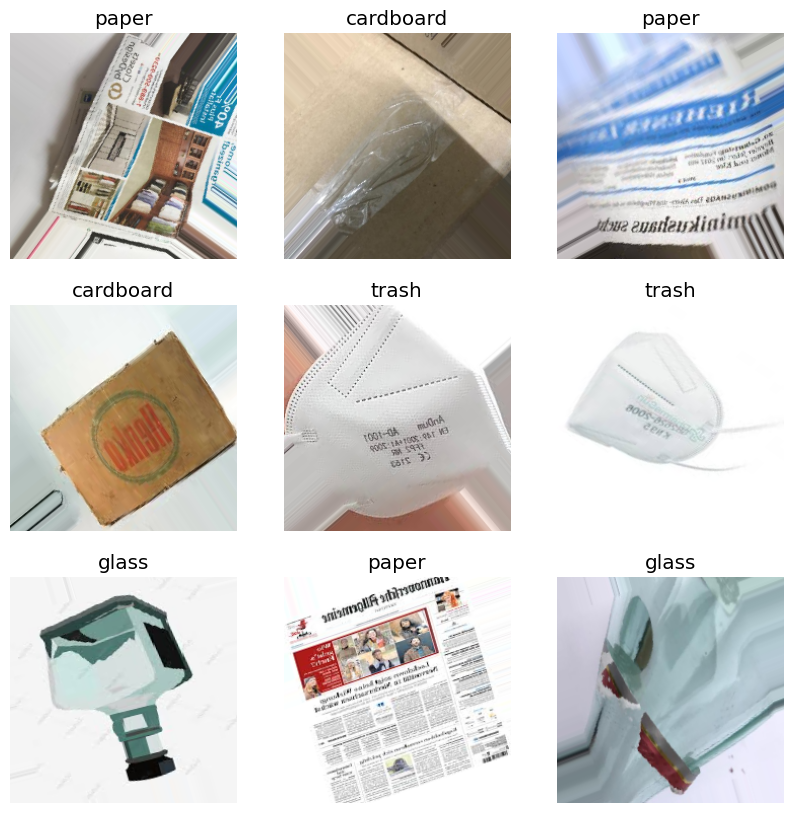

In [15]:
import matplotlib.pyplot as plt
x_batch, y_batch = next(trainGenerator)

plt.figure(figsize=(10,10))
for i in range(9):
    plt.subplot(3,3,i+1)
    plt.imshow(x_batch[i])
    plt.title(list(trainGenerator.class_indices.keys())[y_batch[i].argmax()])
    plt.axis('off')
plt.show()


# ***Modeling (ResNet-50, warmup + fine-tune)***

In [16]:
# --- imports (you can put them with your other imports) ---
import tensorflow as tf
from tensorflow.keras import layers, models, regularizers
from tensorflow.keras.applications import ResNet50
from tensorflow.keras.applications.resnet50 import preprocess_input

NUM_CLASSES = 6  # paper, plastic, cardboard, glass, metal, trash
INPUT_SHAPE = (224, 224, 3)



In [17]:
# --- build model ---
with tf.device('/GPU:0'):
    inp = layers.Input(shape=INPUT_SHAPE)

    # You used rescale=1./255 in your generators; bring it back to 0..255 then apply proper ResNet preprocessing.
    x = layers.Lambda(lambda z: z * 255.0)(inp)
    x = layers.Lambda(preprocess_input, name="resnet50_preprocess")(x)

    base = ResNet50(weights='imagenet', include_top=False, input_tensor=x)

    # a stronger head than Flatten: GAP -> Dense -> BN -> Dropout -> Softmax
    x = layers.GlobalAveragePooling2D(name="gap")(base.output)
    x = layers.Dense(
        256, activation='relu',
        kernel_regularizer=regularizers.l2(1e-4)
    )(x)
    x = layers.BatchNormalization()(x)
    x = layers.Dropout(0.3)(x)
    out = layers.Dense(NUM_CLASSES, activation='softmax', name="pred")(x)

    Model = models.Model(inputs=inp, outputs=out, name="ResNet50_Garbage")

94765736/94765736 ━━━━━━━━━━━━━━━━━━━━ 4s 0us/step


In [18]:

# --- warmup: freeze most of the backbone (keep last 10 layers trainable) ---
for layer in base.layers[:-10]:
    layer.trainable = False

Model.compile(optimizer='adam',
              loss='categorical_crossentropy',
              metrics=['accuracy'])

# --- train (this returns `history` so your plotting cell will work) ---
callbacks = [
    tf.keras.callbacks.EarlyStopping(monitor='val_accuracy', patience=4,
                                     restore_best_weights=True, verbose=1),
    tf.keras.callbacks.ModelCheckpoint('best_resnet50.keras',
                                       monitor='val_accuracy',
                                       save_best_only=True, verbose=1)
]

history = Model.fit(
    trainGenerator,
    validation_data=testGenerator,
    epochs=50,
    verbose=1,
    callbacks=callbacks
)

/usr/local/lib/python3.12/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


Epoch 1/50
67/67 ━━━━━━━━━━━━━━━━━━━━ 0s 806ms/step - accuracy: 0.7339 - loss: 0.8700
Epoch 1: val_accuracy improved from -inf to 0.77632, saving model to best_resnet50.keras
67/67 ━━━━━━━━━━━━━━━━━━━━ 83s 934ms/step - accuracy: 0.7351 - loss: 0.8657 - val_accuracy: 0.7763 - val_loss: 3.2894
Epoch 2/50
67/67 ━━━━━━━━━━━━━━━━━━━━ 0s 666ms/step - accuracy: 0.9098 - loss: 0.3267
Epoch 2: val_accuracy improved from 0.77632 to 0.87895, saving model to best_resnet50.keras
67/67 ━━━━━━━━━━━━━━━━━━━━ 48s 717ms/step - accuracy: 0.9098 - loss: 0.3265 - val_accuracy: 0.8789 - val_loss: 0.6049
Epoch 3/50
67/67 ━━━━━━━━━━━━━━━━━━━━ 0s 668ms/step - accuracy: 0.9293 - loss: 0.2421
Epoch 3: val_accuracy improved from 0.87895 to 0.93026, saving model to best_resnet50.keras
67/67 ━━━━━━━━━━━━━━━━━━━━ 48s 719ms/step - accuracy: 0.9294 - loss: 0.2420 - val_accuracy: 0.9303 - val_loss: 0.2804
Epoch 4/50
67/67 ━━━━━━━━━━━━━━━━━━━━ 0s 672ms/step - accuracy: 0.9525 - loss: 0.1898
Epoch 4: val_accuracy did not

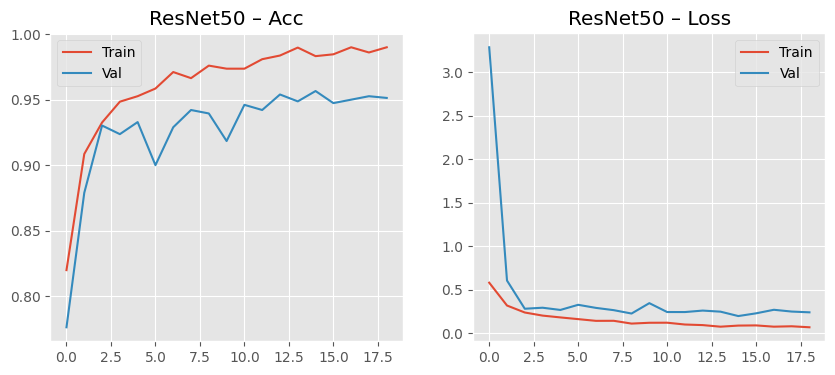

Final Test – Loss: 0.1962  |  Acc: 0.9566


In [19]:
# Accuracy/Loss curves
import matplotlib.pyplot as plt

def plot_hist(h, title=""):
    plt.figure(figsize=(10,4))
    plt.subplot(1,2,1)
    plt.plot(h.history['accuracy'], label='Train')
    plt.plot(h.history['val_accuracy'], label='Val')
    plt.title(title+'Acc'); plt.legend()

    plt.subplot(1,2,2)
    plt.plot(h.history['loss'], label='Train')
    plt.plot(h.history['val_loss'], label='Val')
    plt.title(title+'Loss'); plt.legend()
    plt.show()

plot_hist(history, "ResNet50 – ")

# only plot fine-tune if it exists
if 'history_ft' in globals():
    plot_hist(history_ft, "ResNet50 FT – ")

# Final test metrics
test_metrics = Model.evaluate(testGenerator, verbose=0)
print(f"Final Test – Loss: {test_metrics[0]:.4f}  |  Acc: {test_metrics[1]:.4f}")



In [20]:
# Unfreeze last 50 layers and fine-tune with small LR
for layer in Model.layers:
    if hasattr(layer, "trainable"):
        layer.trainable = True  # or: for layer in base.layers[-50:]: layer.trainable = True

Model.compile(optimizer=tf.keras.optimizers.Adam(1e-5),
              loss='categorical_crossentropy', metrics=['accuracy'])

history_ft = Model.fit(
    trainGenerator,
    validation_data=testGenerator,
    epochs=10,
    verbose=1,
    callbacks=[tf.keras.callbacks.EarlyStopping(
        monitor='val_accuracy', patience=3, restore_best_weights=True
    )]
)


Epoch 1/10
67/67 ━━━━━━━━━━━━━━━━━━━━ 147s 1s/step - accuracy: 0.9252 - loss: 0.2889 - val_accuracy: 0.9566 - val_loss: 0.1760
Epoch 2/10
67/67 ━━━━━━━━━━━━━━━━━━━━ 50s 743ms/step - accuracy: 0.9713 - loss: 0.1286 - val_accuracy: 0.9553 - val_loss: 0.1817
Epoch 3/10
67/67 ━━━━━━━━━━━━━━━━━━━━ 49s 724ms/step - accuracy: 0.9757 - loss: 0.1106 - val_accuracy: 0.9500 - val_loss: 0.1866
Epoch 4/10
67/67 ━━━━━━━━━━━━━━━━━━━━ 50s 734ms/step - accuracy: 0.9850 - loss: 0.0828 - val_accuracy: 0.9500 - val_loss: 0.1816


In [21]:
# class mapping to indices
print(trainGenerator.class_indices)

# Confusion matrix on test set
import numpy as np
from sklearn.metrics import confusion_matrix, classification_report

y_true = testGenerator.classes
y_pred = Model.predict(testGenerator, verbose=0)
y_pred = np.argmax(y_pred, axis=1)

print(classification_report(y_true, y_pred, target_names=list(trainGenerator.class_indices.keys())))


{'cardboard': 0, 'glass': 1, 'metal': 2, 'paper': 3, 'plastic': 4, 'trash': 5}
              precision    recall  f1-score   support

   cardboard       0.99      0.99      0.99       134
       glass       0.96      0.87      0.91       117
       metal       0.90      0.97      0.93       116
       paper       0.98      0.99      0.99       158
     plastic       0.92      0.94      0.93       130
       trash       0.99      0.96      0.98       105

    accuracy                           0.96       760
   macro avg       0.96      0.95      0.95       760
weighted avg       0.96      0.96      0.96       760



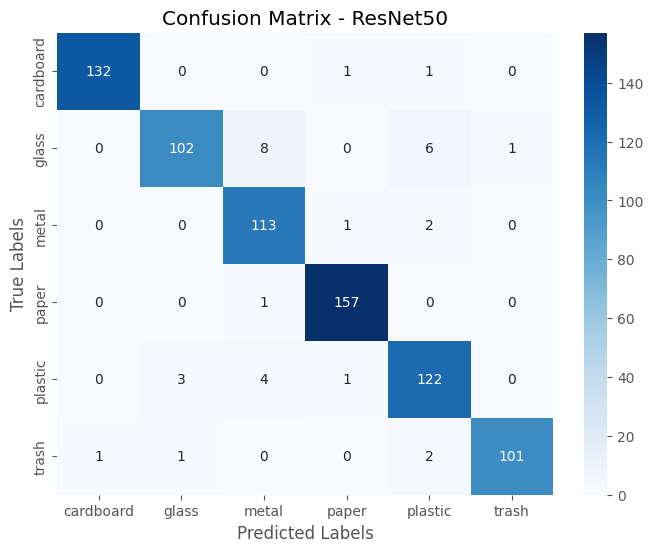

In [22]:
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix

# Compute confusion matrix
cm = confusion_matrix(y_true, y_pred)
class_names = list(trainGenerator.class_indices.keys())

# Plot confusion matrix
plt.figure(figsize=(8,6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=class_names, yticklabels=class_names)
plt.xlabel('Predicted Labels')
plt.ylabel('True Labels')
plt.title('Confusion Matrix - ResNet50')
plt.show()


# ***Show 24 random predictions***

In [23]:
import numpy as np
import matplotlib.pyplot as plt

images = []
predictedClasses = []
trueClasses = []

# Get class labels from generator
class_labels = list(testGenerator.class_indices.keys())

# Collect some samples from the test set
for i in range(len(testGenerator)):
    img_batch, true_labels_batch = next(testGenerator)
    true_class_idx = np.argmax(true_labels_batch[0])         # true label
    prediction = Model.predict(img_batch)                    # predict
    predicted_class_idx = np.argmax(prediction[0])           # predicted label

    # Convert indices to readable labels
    predicted_class = class_labels[predicted_class_idx]
    true_class = class_labels[true_class_idx]

    images.append(np.squeeze(img_batch[0]))
    predictedClasses.append(predicted_class)
    trueClasses.append(true_class)

    if i >= 24:     # show only 24 images
        break


1/1 ━━━━━━━━━━━━━━━━━━━━ 4s 4s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 71ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 68ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 67ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 68ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 68ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 69ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 66ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 69ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 67ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 66ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 67ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 67ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 67ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 66ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 67ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 67ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 69ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 66ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 66ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 67ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 68ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 67ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 67ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 67ms/step


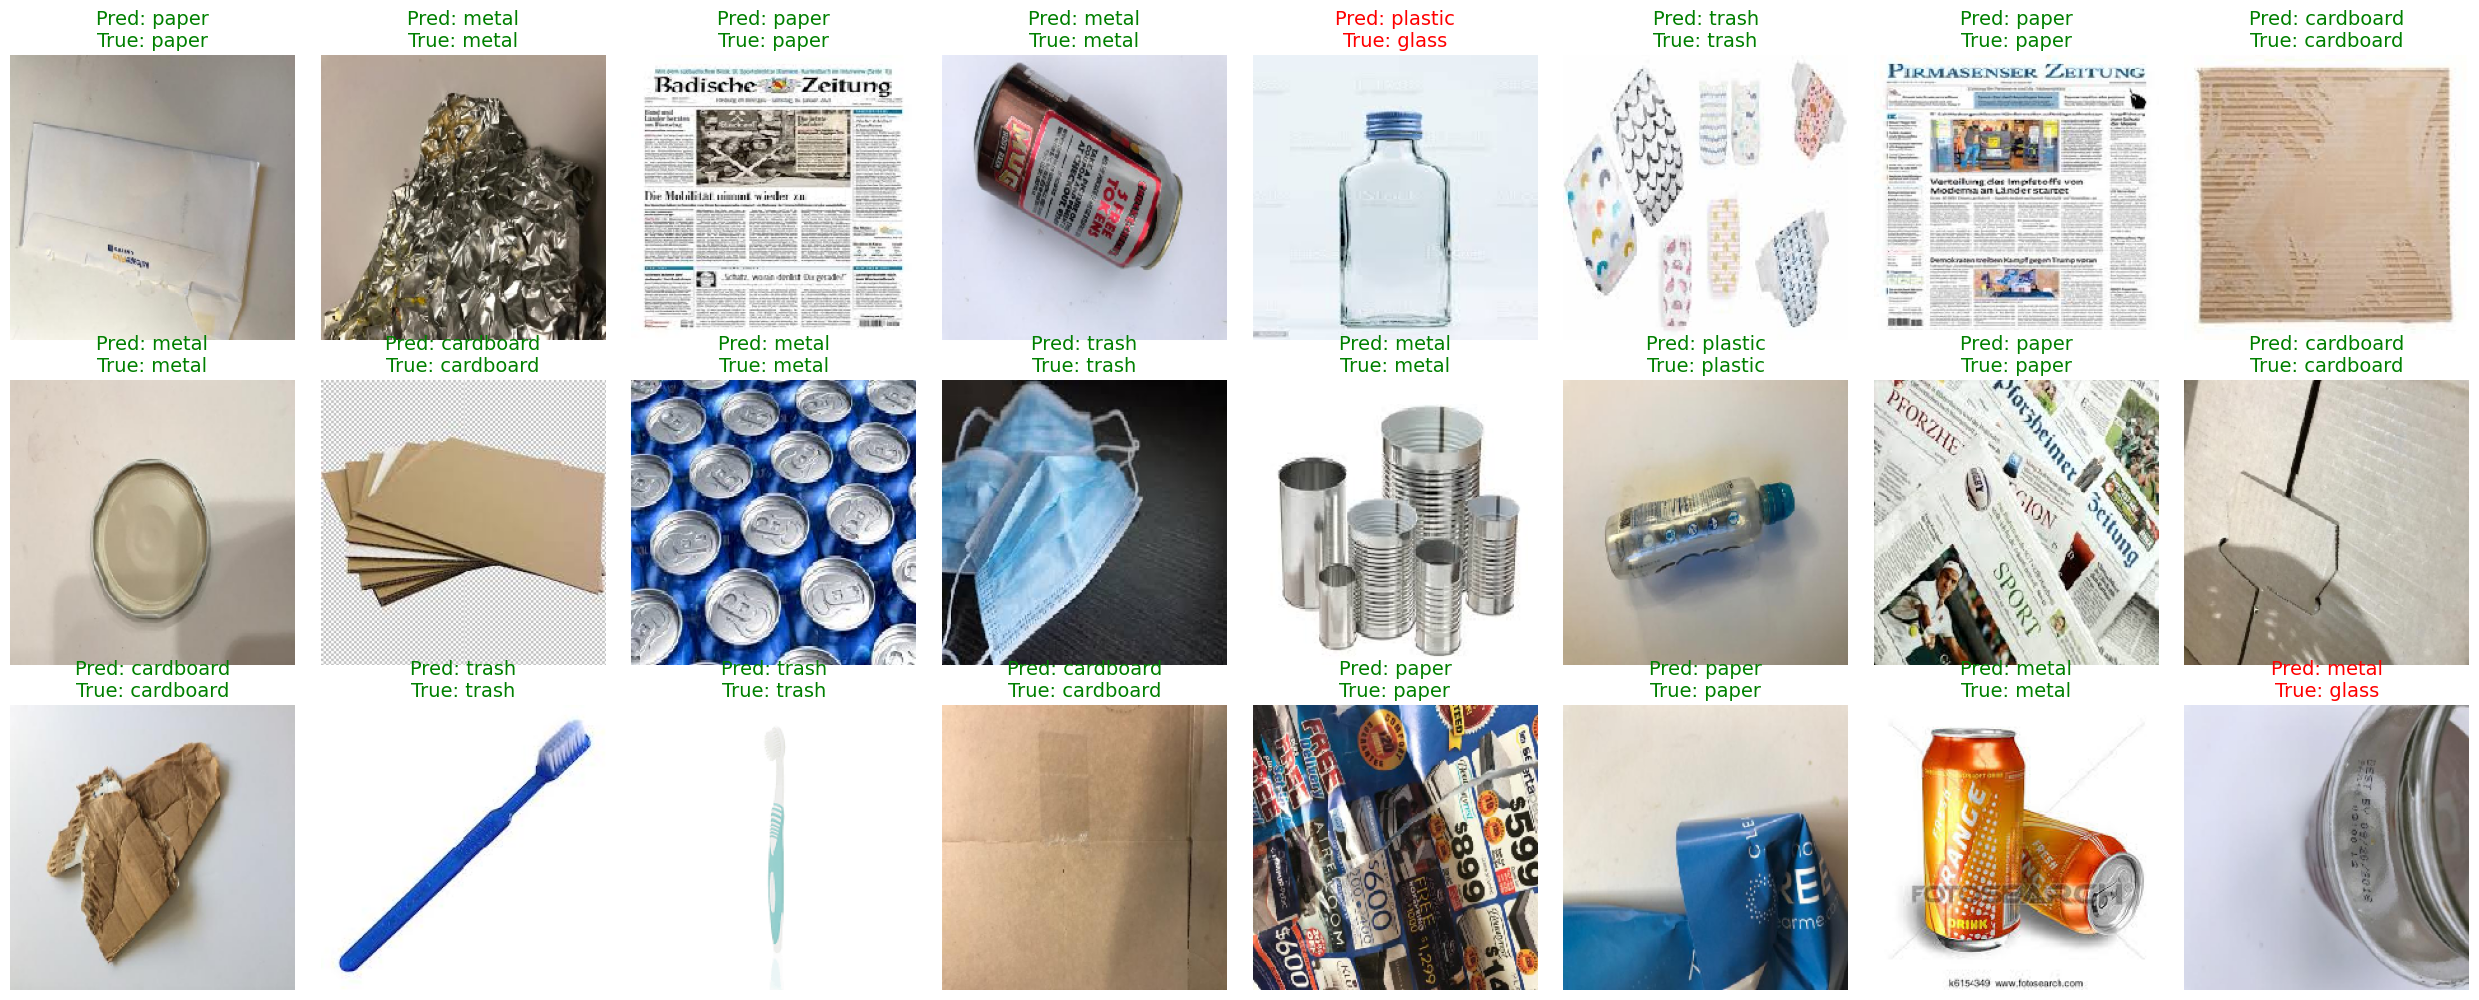

In [24]:
fig, axes = plt.subplots(3, 8, figsize=(25, 10))
axes = axes.flatten()

for ax, img, pred, true in zip(axes, images, predictedClasses, trueClasses):
    ax.imshow(img)
    color = "green" if pred == true else "red"
    ax.set_title(f"Pred: {pred}\nTrue: {true}", fontsize=14, color=color)
    ax.axis("off")

plt.tight_layout()
plt.show()


# ***Demo type A***

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 74ms/step


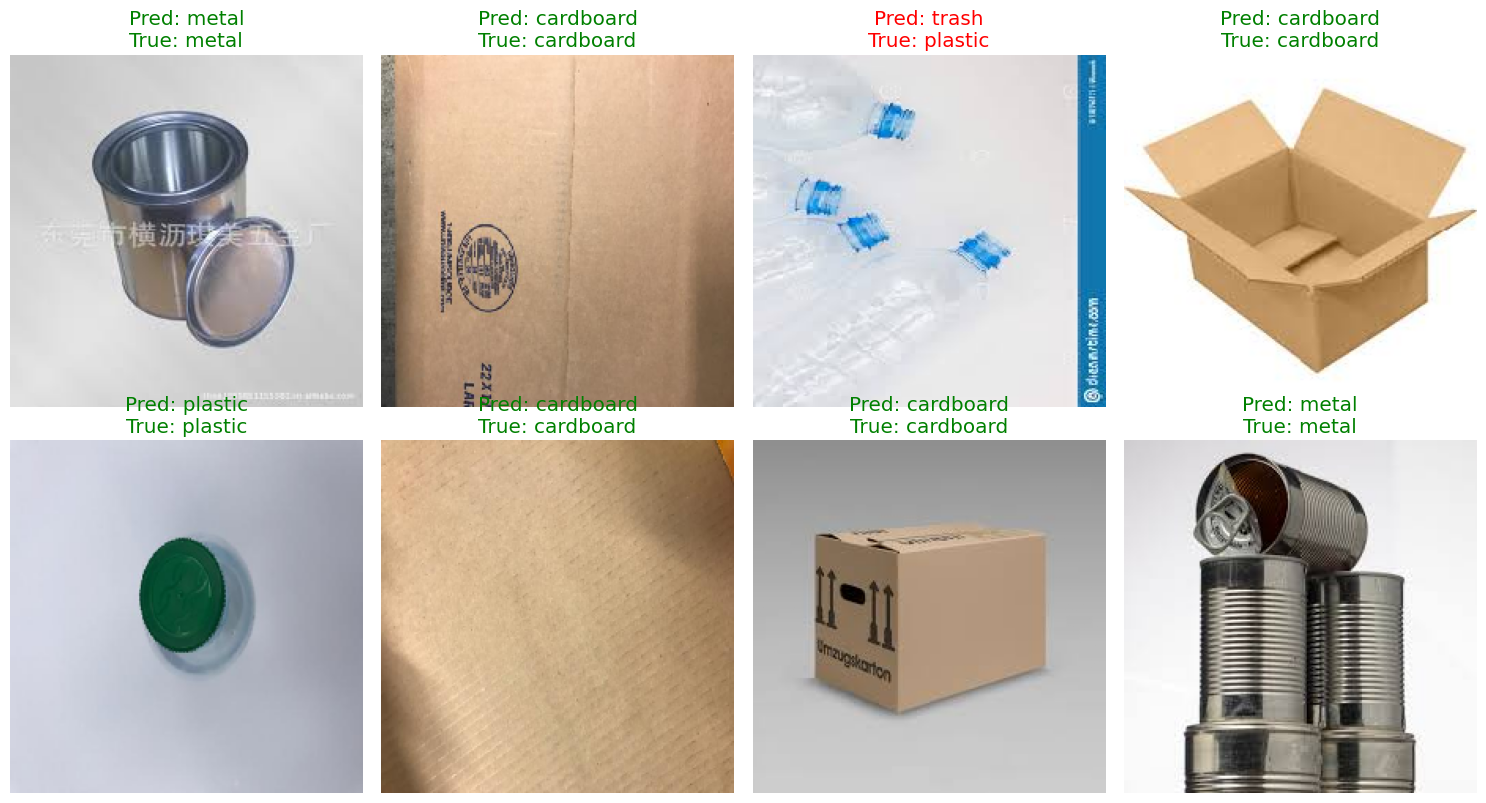

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# Pick 8 random samples from the test generator
x_batch, y_batch = next(testGenerator)

# Predict
predictions = Model.predict(x_batch)

# Convert indices to class labels
class_labels = list(testGenerator.class_indices.keys())
predicted_classes = np.argmax(predictions, axis=1)
true_classes = np.argmax(y_batch, axis=1)

# Plot 8 sample predictions
plt.figure(figsize=(15, 8))
for i in range(8):
    ax = plt.subplot(2, 4, i + 1)
    plt.imshow(x_batch[i])
    pred = class_labels[predicted_classes[i]]
    true = class_labels[true_classes[i]]
    color = "green" if pred == true else "red"
    plt.title(f"Pred: {pred}\nTrue: {true}", color=color)
    plt.axis("off")

plt.tight_layout()
plt.show()


# ***Demo type B***

Saving paper10.jpg to paper10.jpg
1/1 ━━━━━━━━━━━━━━━━━━━━ 5s 5s/step


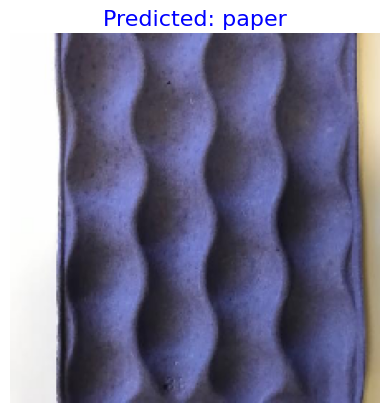

 The model predicts: **PAPER**


In [ ]:
from google.colab import files
from tensorflow.keras.preprocessing import image
import numpy as np
import matplotlib.pyplot as plt

# Upload your own picture
uploaded = files.upload()

for filename in uploaded.keys():
    # Load and preprocess the image
    img_path = filename
    img = image.load_img(img_path, target_size=(224, 224))  # same size as your model
    img_array = image.img_to_array(img)
    img_array = np.expand_dims(img_array, axis=0) / 255.0    # rescale like testGenerator

    # Predict
    prediction = Model.predict(img_array)
    class_labels = list(testGenerator.class_indices.keys())
    predicted_class = class_labels[np.argmax(prediction)]

    # Show image and prediction
    plt.imshow(img)
    plt.axis('off')
    plt.title(f"Predicted: {predicted_class}", fontsize=16, color='blue')
    plt.show()

    print(f" The model predicts: **{predicted_class.upper()}**")


# ***Demo type 3***

In [25]:
!pip install gradio -q
import gradio as gr
import numpy as np
from tensorflow.keras.preprocessing import image
import tensorflow as tf

# Load your trained model
# Model = tf.keras.models.load_model('resnet50_garbage.h5')  # uncomment if saved

# Get class labels from your test generator
class_labels = list(testGenerator.class_indices.keys())

# Define prediction function
def classify_image(img):
    img = img.resize((224, 224))
    img_array = np.expand_dims(np.array(img) / 255.0, axis=0)
    preds = Model.predict(img_array)
    pred_idx = np.argmax(preds)
    confidence = float(np.max(preds))
    label = class_labels[pred_idx]
    return {label: confidence}

# Create Gradio interface
demo = gr.Interface(
    fn=classify_image,
    inputs=gr.Image(type="pil", label="Upload an Image"),
    outputs=gr.Label(num_top_classes=3, label="Prediction"),
    title="♻️ Garbage Classification ",
    description="Upload an image of garbage (metal, glass, paper, trash, cardboard, or plastic) and let the AI classify it!",
    theme="soft",
)

# Launch the app
demo.launch(share=True)


Colab notebook detected. To show errors in colab notebook, set debug=True in launch()
* Running on public URL: https://7f46fa00d934532d3e.gradio.live

This share link expires in 1 week. For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)


In [26]:
# 1. Save the trained model
Model.save("resnet50_garbage.keras")   # or "resnet50_garbage.h5"


In [27]:
import json

# class_indices: {'cardboard':0, 'glass':1, ...}
class_indices = trainGenerator.class_indices

# convert to index → class mapping so we can go from prediction index to label
idx_to_class = {v: k for k, v in class_indices.items()}
print(idx_to_class)

with open("idx_to_class.json", "w") as f:
    json.dump(idx_to_class, f)


{0: 'cardboard', 1: 'glass', 2: 'metal', 3: 'paper', 4: 'plastic', 5: 'trash'}
